# Analyse jeu de données + data viz

## import des données et description générale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

main_data="data_final_streamlit"

df = pd.read_csv('data/avis_40k.csv', sep=';', header=0)

print('chargement des données et description rapide.')

display(df.head())
display(df.info())
display(df.describe())


chargement des données et description rapide.


,auteur,note,titre,commentaire,date_experience,date_avis,url,texteServiceReply,dateServiceReply,dataServiceReply
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",A day ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
1,Patrice,5,Comportement professionnel,NaN,"February 11, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
3,Derek Mcmillan,5,Excellent.,NaN,"February 4, 2026","Feb 4, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 5, 2026","Bonjour Derek, Je vous remercie pour votre ret..."
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre..."


<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   auteur             40000 non-null  str  
 1   note               40000 non-null  int64
 2   titre              40000 non-null  str  
 3   commentaire        36225 non-null  str  
 4   date_experience    40000 non-null  str  
 5   date_avis          40000 non-null  str  
 6   url                40000 non-null  str  
 7   texteServiceReply  33146 non-null  str  
 8   dateServiceReply   33146 non-null  str  
 9   dataServiceReply   33146 non-null  str  
dtypes: int64(1), str(9)
memory usage: 22.2 MB


None

,note
count,40000.00000
mean,4.02915
std,1.40819
min,1.00000
25%,3.00000
50%,5.00000
75%,5.00000
max,5.00000


## traitement des Na et suppression de variables inutiles

traitement des NaN
3775
pourcentage Na parmi les avis: 9.4375
            auteur  note                           titre commentaire  \
1          Patrice     5      Comportement professionnel         NaN   
3   Derek Mcmillan     5                      Excellent.         NaN   
7     Masnou Bruno     5      Super.....................         NaN   
16          Anouar     5                  Good good good         NaN   
19           Aslan     1  Nulle je déconseille set sites         NaN   

      date_experience     date_avis  \
1   February 11, 2026    3 days ago   
3    February 4, 2026   Feb 4, 2026   
7    January 15, 2026  Jan 16, 2026   
16  December 15, 2025  Dec 17, 2025   
19  November 27, 2025  Nov 27, 2025   

                                             url  texteServiceReply  \
1   https://www.trustpilot.com/review/oscaro.com                NaN   
3   https://www.trustpilot.com/review/oscaro.com  Reply from Oscaro   
7   https://www.trustpilot.com/review/oscaro.com  Reply f

Text(0.5, 1.0, 'Proportion de NaN parmi les avis clients')

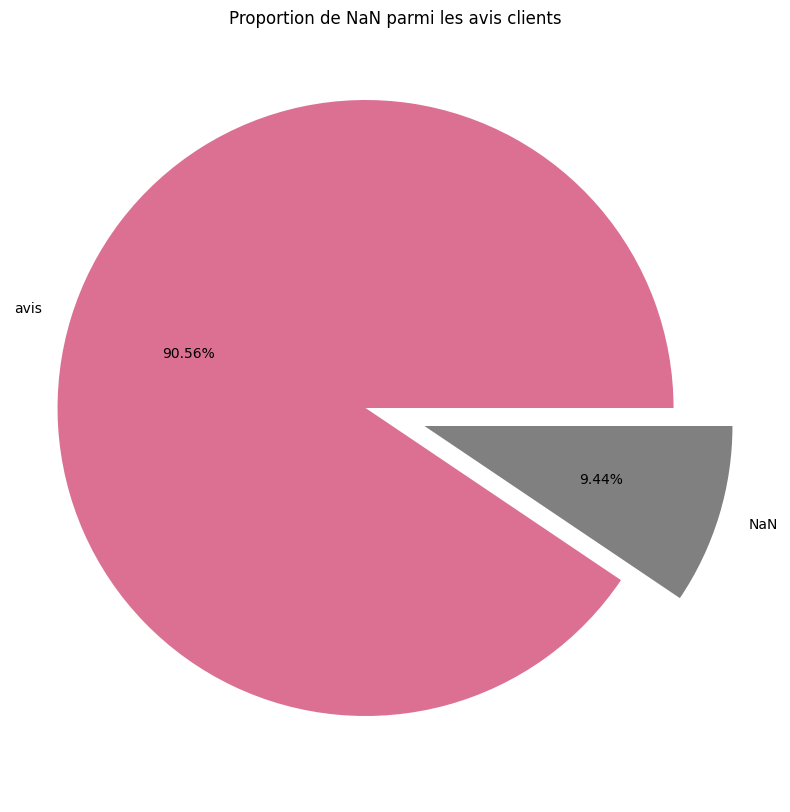

In [2]:
print('traitement des NaN')

print(df['commentaire'].isna().sum())
print('pourcentage Na parmi les avis:', df['commentaire'].isna().sum()/len(df['commentaire'])*100)
print(df[df['commentaire'].isna()].head())


plt.figure(figsize=(10,10))
plt.pie(df["commentaire"].isna().value_counts(normalize=True),
            labels=['avis', 'NaN'],
            explode=[0.1, 0.1],
            autopct="%0.2f%%",
            colors=["palevioletred", "grey"])
plt.title('Proportion de NaN parmi les avis clients')

In [3]:
df['commentaire'] = df['commentaire'].fillna(df['titre']) # remplacement na par titre
df[['commentaire', 'auteur', 'date_avis']] = df[['commentaire', 'auteur', 'date_avis']].drop_duplicates()
df = df.drop('date_avis', axis=1) # suppression date avis, on garde uniquement date experience
df = df.drop('texteServiceReply', axis=1) # suppression de la variable car n'apporte pas d'info
df = df.drop('url', axis = 1)
df = df.drop('dateServiceReply', axis = 1)

display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   auteur            39948 non-null  str  
 1   note              40000 non-null  int64
 2   titre             40000 non-null  str  
 3   commentaire       39948 non-null  str  
 4   date_experience   40000 non-null  str  
 5   dataServiceReply  33146 non-null  str  
dtypes: int64(1), str(5)
memory usage: 17.2 MB


None

,auteur,note,titre,commentaire,date_experience,dataServiceReply
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",NaN
1,Patrice,5,Comportement professionnel,Comportement professionnel,"February 11, 2026",NaN
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",NaN
3,Derek Mcmillan,5,Excellent.,Excellent.,"February 4, 2026","Bonjour Derek, Je vous remercie pour votre ret..."
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Bonjour Grégoire , Je vous remercie pour votre..."


## Traitement de la langue dans le corpus d'avis

In [4]:
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 34 # il est important de spécifier la graine car langdetect n'est pas déterministe

def to_detect(text_i): # détection de la langue
    try :
        return detect(text_i)
    except:
        return ('NA')

df["lang"] = df["commentaire"].apply(lambda x: to_detect(x))
print(df['lang'].value_counts())
print(df['lang'].describe(include='O'))




lang
fr    38261
ca      360
es      316
en      289
de      128
it      123
pt      122
ro      105
NA       78
nl       47
vi       25
lv       18
id       16
af       16
hu       13
sk       11
et       10
fi        9
so        7
sv        7
pl        6
tl        6
da        5
lt        4
sq        4
tr        3
no        3
cy        3
bg        1
ru        1
cs        1
sw        1
hr        1
Name: count, dtype: int64
count     40000
unique       33
top          fr
freq      38261
Name: lang, dtype: object


In [5]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   auteur            39948 non-null  str  
 1   note              40000 non-null  int64
 2   titre             40000 non-null  str  
 3   commentaire       39948 non-null  str  
 4   date_experience   40000 non-null  str  
 5   dataServiceReply  33146 non-null  str  
 6   lang              40000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.5 MB


None

In [6]:
df.to_csv(f'{main_data}/40k_langdetect.csv') # export du df processé pour la langue

In [7]:
test = pd.read_csv(f'{main_data}/40k_langdetect.csv', sep=',', header=0, index_col=0)
test.head()

,auteur,note,titre,commentaire,date_experience,dataServiceReply,lang
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",NaN,fr
1,Patrice,5,Comportement professionnel,Comportement professionnel,"February 11, 2026",NaN,fr
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",NaN,hu
3,Derek Mcmillan,5,Excellent.,Excellent.,"February 4, 2026","Bonjour Derek, Je vous remercie pour votre ret...",ca
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Bonjour Grégoire , Je vous remercie pour votre...",fr


Text(0, 0.5, "nombre d'occurences")

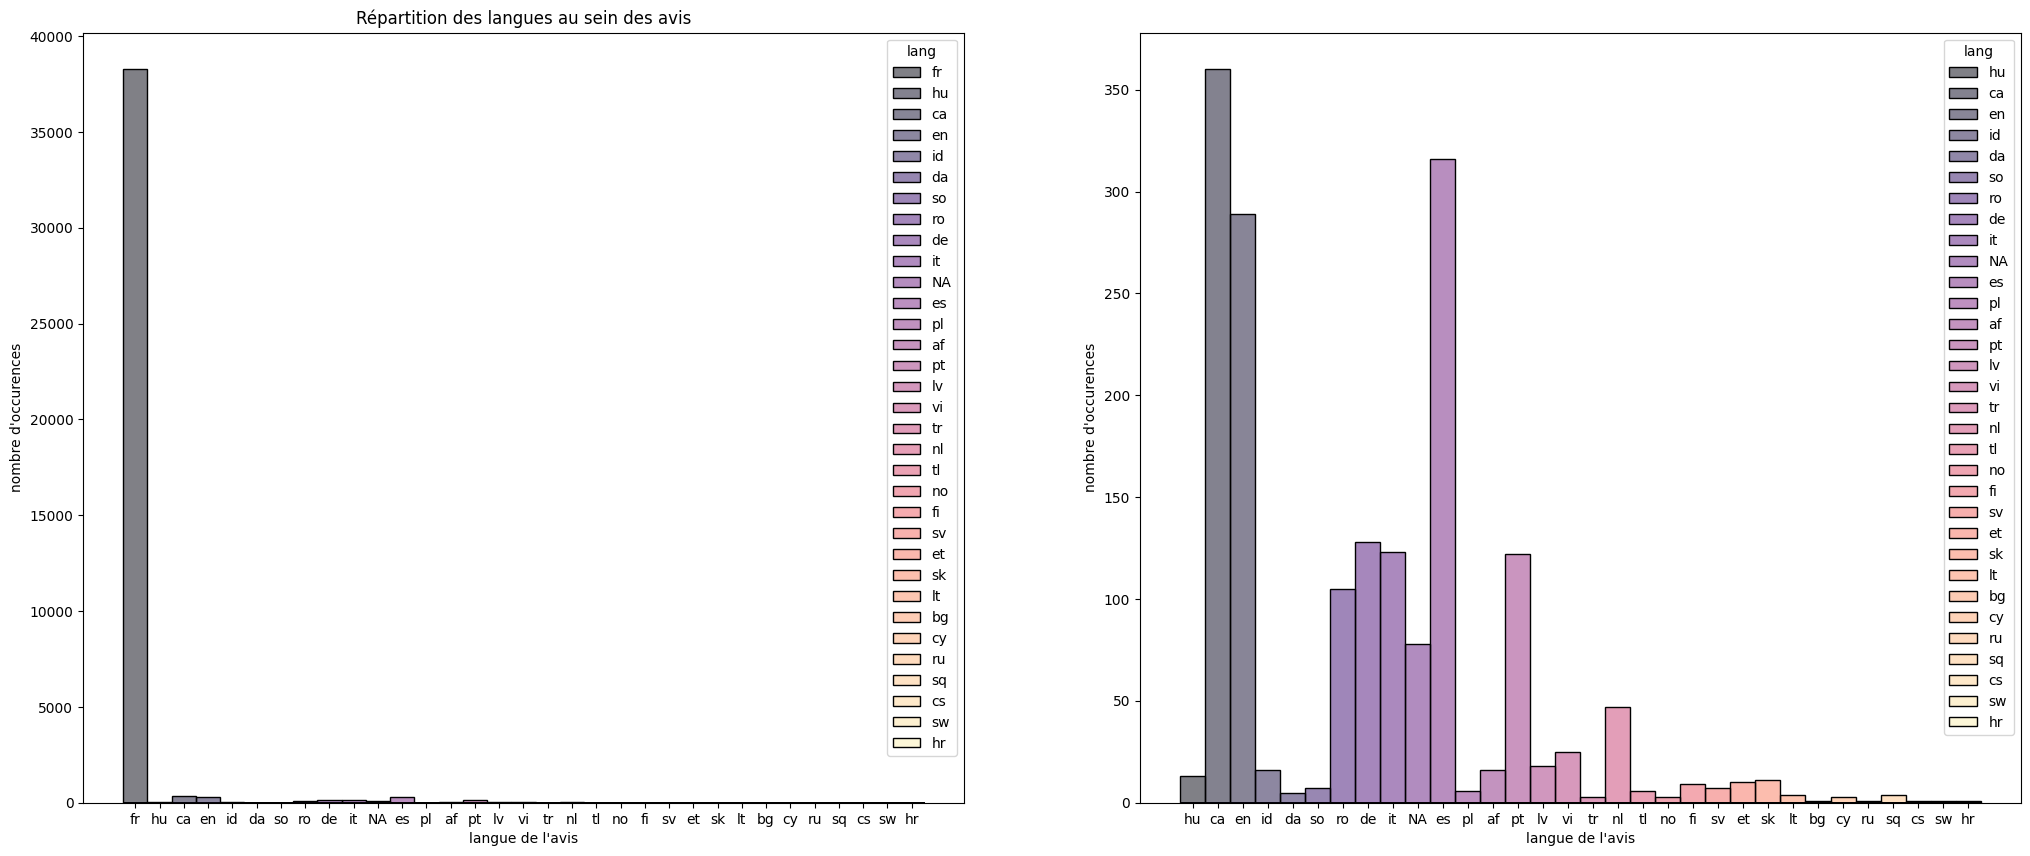

In [8]:

plt.figure(figsize=(25,10))

plt.subplot(121)
plt.title('Répartition des langues au sein des avis')
sns.histplot(data=df, x= 'lang', hue='lang', palette='magma')
plt.xlabel('langue de l\'avis')
plt.ylabel('nombre d\'occurences')
plt.subplot(122)
sns.histplot(data=df.loc[df['lang']!='fr'], x= 'lang', hue='lang', palette='magma')
plt.xlabel('langue de l\'avis')
plt.ylabel('nombre d\'occurences')

In [9]:
df = df[df["lang"] == "fr"] # on conserve uniquement les avis en français
df = df.dropna(subset=['commentaire'])
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   auteur            38261 non-null  str  
 1   note              38261 non-null  int64
 2   titre             38261 non-null  str  
 3   commentaire       38261 non-null  str  
 4   date_experience   38261 non-null  str  
 5   dataServiceReply  31736 non-null  str  
 6   lang              38261 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.3 MB


## création nouvelles variables

In [10]:

month_to_number = {'January' : 1, 'February' : 2, 'March' : 3, 'April' : 4, 'May' : 5, 'June' : 6, 'July' : 7, 'August' : 8, 'September' : 9, 'October' : 10, 'November' : 11, 'December' : 12}

df['date_experience_year'] = df['date_experience'].str[-4:] # transformation variable date_experience en 2 variables: année et mois
df['date_experience_month'] = df['date_experience'].replace(month_to_number, regex=True).astype(int)
df['date_experience_year'] = df['date_experience_year'].astype(int)
df = df.drop('date_experience', axis=1)

# création comm_reply : fusion avis + réponse entreprise
df['comm_reply'] = np.where(df['dataServiceReply'].isna() == False, df['commentaire'] + df['dataServiceReply'], df['commentaire'])

# création length_comm : taille de l'avis
df['length_comm'] = df['commentaire'].apply(lambda x: len(x))



df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   auteur                 38261 non-null  str  
 1   note                   38261 non-null  int64
 2   titre                  38261 non-null  str  
 3   commentaire            38261 non-null  str  
 4   dataServiceReply       31736 non-null  str  
 5   lang                   38261 non-null  str  
 6   date_experience_year   38261 non-null  int64
 7   date_experience_month  38261 non-null  int64
 8   comm_reply             38261 non-null  str  
 9   length_comm            38261 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.5 MB


,auteur,note,titre,commentaire,dataServiceReply,lang,date_experience_year,date_experience_month,comm_reply,length_comm
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,NaN,fr,2026,2,Produit conforme. La description du contenue e...,136
1,Patrice,5,Comportement professionnel,Comportement professionnel,NaN,fr,2026,2,Comportement professionnel,26
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"Bonjour Grégoire , Je vous remercie pour votre...",fr,2026,1,Tres bien mais attention bien scotcher les col...,100
5,eric petitot,4,Piece conforme mais la gaine de…,Piece conforme mais la gaine de protection sur...,"Bonjour Eric, Je vous remercie pour votre reto...",fr,2026,1,Piece conforme mais la gaine de protection sur...,114
9,Moha,5,Enjoliveur par choc,"Simple, rapide et efficace.","Bonjour Mohamed, Je vous remercie pour votre r...",fr,2026,1,"Simple, rapide et efficace.Bonjour Mohamed, Je...",27


## Proportion finale Na

In [11]:



print("Evaluation de la part des données manquantes: ", end="\n\n")

for i in df.columns :
    print(i)
    print(df[i].isna().sum()/len(df[i])*100, end="\n\n")


df.info()
df.head()

Evaluation de la part des données manquantes: 

auteur
0.0

note
0.0

titre
0.0

commentaire
0.0

dataServiceReply
17.053919134366588

lang
0.0

date_experience_year
0.0

date_experience_month
0.0

comm_reply
0.0

length_comm
0.0

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   auteur                 38261 non-null  str  
 1   note                   38261 non-null  int64
 2   titre                  38261 non-null  str  
 3   commentaire            38261 non-null  str  
 4   dataServiceReply       31736 non-null  str  
 5   lang                   38261 non-null  str  
 6   date_experience_year   38261 non-null  int64
 7   date_experience_month  38261 non-null  int64
 8   comm_reply             38261 non-null  str  
 9   length_comm            38261 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.5 MB


,auteur,note,titre,commentaire,dataServiceReply,lang,date_experience_year,date_experience_month,comm_reply,length_comm
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,NaN,fr,2026,2,Produit conforme. La description du contenue e...,136
1,Patrice,5,Comportement professionnel,Comportement professionnel,NaN,fr,2026,2,Comportement professionnel,26
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"Bonjour Grégoire , Je vous remercie pour votre...",fr,2026,1,Tres bien mais attention bien scotcher les col...,100
5,eric petitot,4,Piece conforme mais la gaine de…,Piece conforme mais la gaine de protection sur...,"Bonjour Eric, Je vous remercie pour votre reto...",fr,2026,1,Piece conforme mais la gaine de protection sur...,114
9,Moha,5,Enjoliveur par choc,"Simple, rapide et efficace.","Bonjour Mohamed, Je vous remercie pour votre r...",fr,2026,1,"Simple, rapide et efficace.Bonjour Mohamed, Je...",27


## Distribution des notes et de la taille des commentaires

Text(0.5, 1.0, 'taille médiane des commentaires en fonction de la note')

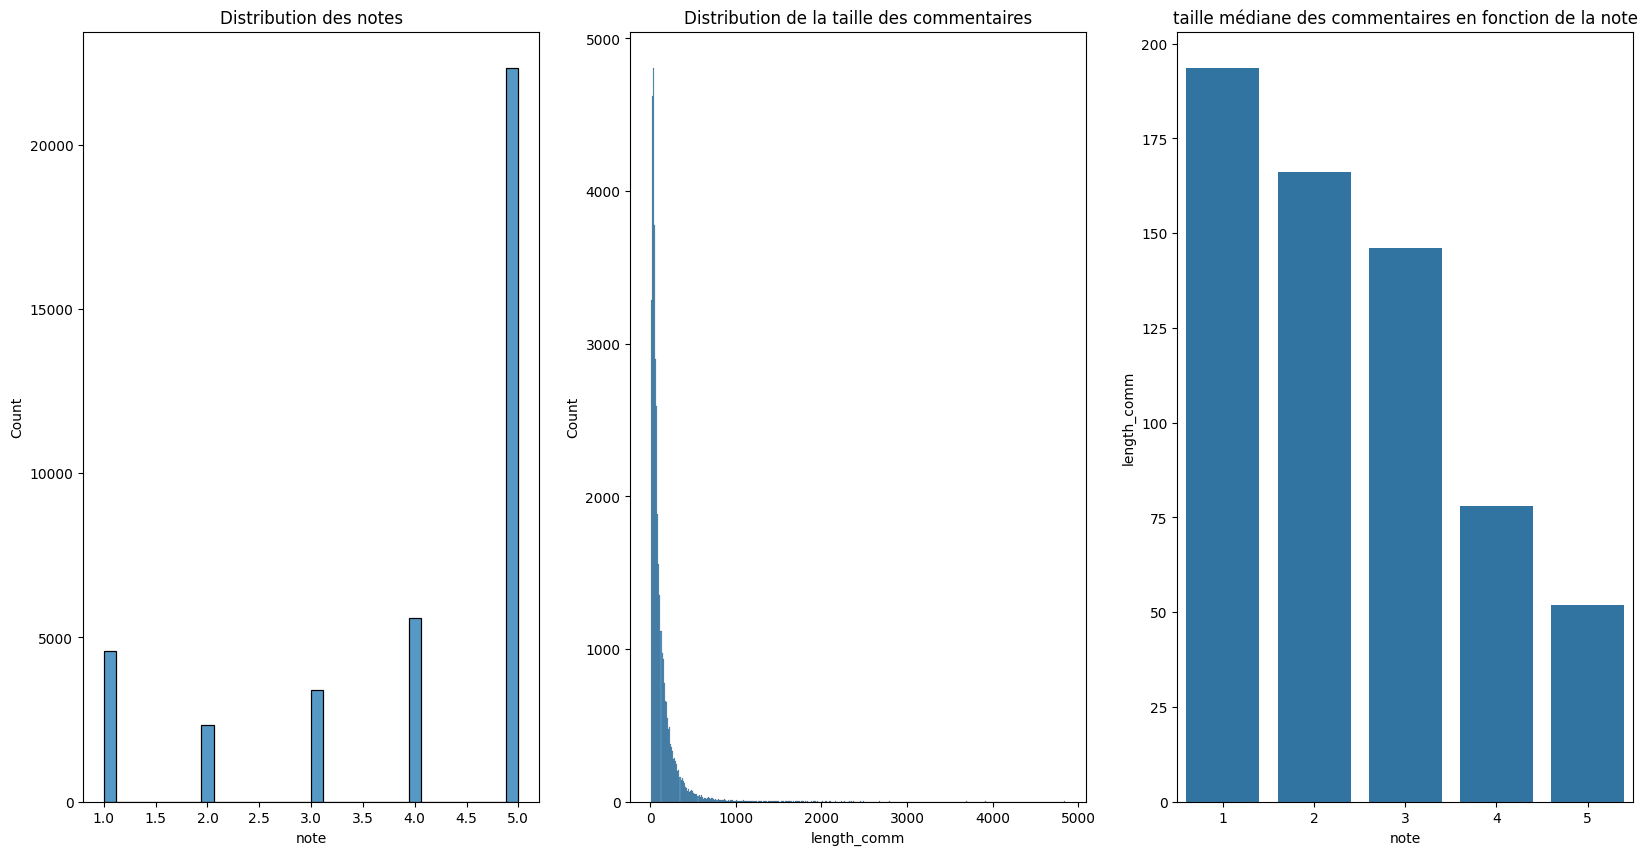

In [12]:


plt.figure(figsize=(20,10))

plt.subplot(131)

sns.histplot(df['note'])
plt.title('Distribution des notes')

plt.subplot(132)

sns.histplot(df['length_comm'])
plt.title('Distribution de la taille des commentaires')

plt.subplot(133)

sns.barplot(data= df[['note','length_comm']].groupby('note').median(), x='note', y='length_comm')
plt.title('taille médiane des commentaires en fonction de la note')


## Corrélation taille commentaire / note

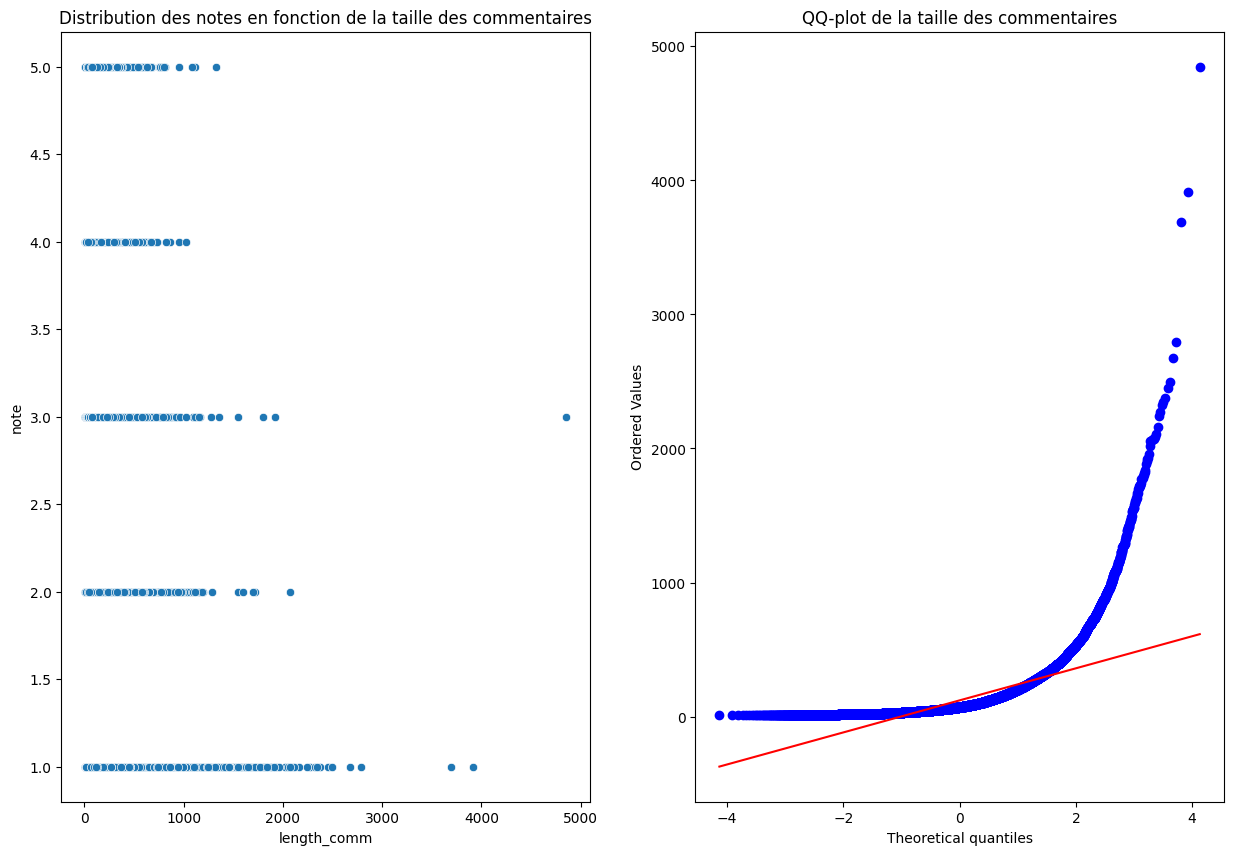

                note  length_comm
note         1.00000     -0.46309
length_comm -0.46309      1.00000
normalité des données, shapiro's p.value: 1.34296855086009e-77
pearson correlation coef: -0.46308957127179984
pearson correlation p.value: 0.0
kendall correlation coef: -0.3734948642650401
kendall correlation p.value: 0.0


In [13]:
import scipy.stats as ss

plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.scatterplot(x=df['length_comm'], y=df['note'])
plt.title('Distribution des notes en fonction de la taille des commentaires')
plt.subplot(122)
ss.probplot(df['length_comm'], plot=plt)
plt.title('QQ-plot de la taille des commentaires')
plt.show()


print(df[['note', 'length_comm']].corr())

print('normalité des données, shapiro\'s p.value:', ss.shapiro(df['length_comm'].head(5000))[1])
print('pearson correlation coef:', ss.pearsonr(df['length_comm'], df['note'])[0])
print('pearson correlation p.value:', ss.pearsonr(df['length_comm'], df['note'])[1])
print('kendall correlation coef:', ss.kendalltau(df['length_comm'], df['note'])[0])
print('kendall correlation p.value:', ss.kendalltau(df['length_comm'], df['note'])[1])

## Répartition temporelle du jeu de données

date_experience_month
5     0.130708
11    0.104336
8     0.102925
6     0.100991
10    0.098691
7     0.098037
1     0.086407
12    0.086171
9     0.074018
4     0.065367
2     0.045529
3     0.006822
Name: proportion, dtype: float64

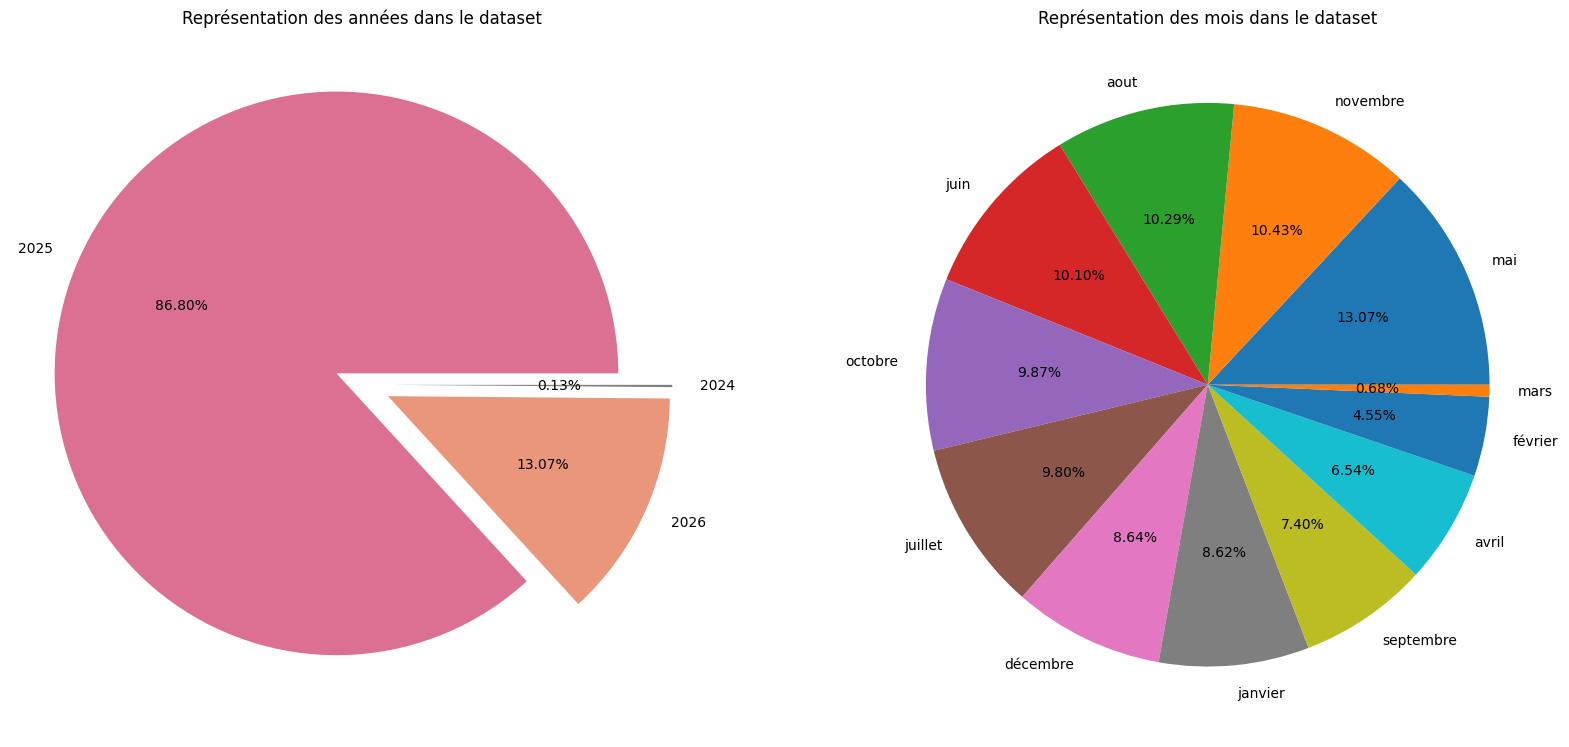

In [14]:
plt.figure(figsize=(20,10))

plt.subplot(121)

plt.pie(df["date_experience_year"].value_counts(normalize=True),
            labels=['2025', '2026', '2024'],
            explode=[0.1, 0.1, 0.1],
            autopct="%0.2f%%",
            colors=["palevioletred", "darksalmon", "grey"])
plt.title('Représentation des années dans le dataset')

plt.subplot(122)

plt.pie(df["date_experience_month"].value_counts(normalize=True),
            labels=['mai', 'novembre', 'aout', 'juin', 'octobre', 'juillet', 'décembre', 'janvier', 'septembre', 'avril', 'février', 'mars'],
            #explode=[0.1, 0.1, 0.1],
            autopct="%0.2f%%")
            #colors=["palevioletred", "darksalmon", "grey"])
plt.title('Représentation des mois dans le dataset')


df["date_experience_month"].value_counts(normalize=True)

## Light Cleaning

In [15]:
import re

def clean_text(text):
    try:
        text = re.sub(r"http\S+", "", text)        # URLs
        text = re.sub(r"<.*?>", "", text)          # HTML
        text = re.sub(r"\S+@\S+", "", text)        # emails
        text = re.sub(r"\s+", " ", text).strip()   # espaces multiples
    except TypeError :
        text = np.nan
    return text


df['commentaire'] = df['commentaire'].apply(lambda x: clean_text(x))
df['dataServiceReply'] = df['dataServiceReply'].apply(lambda x: clean_text(x))





df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 38261 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   auteur                 38261 non-null  str  
 1   note                   38261 non-null  int64
 2   titre                  38261 non-null  str  
 3   commentaire            38261 non-null  str  
 4   dataServiceReply       31736 non-null  str  
 5   lang                   38261 non-null  str  
 6   date_experience_year   38261 non-null  int64
 7   date_experience_month  38261 non-null  int64
 8   comm_reply             38261 non-null  str  
 9   length_comm            38261 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.5 MB


,auteur,note,titre,commentaire,dataServiceReply,lang,date_experience_year,date_experience_month,comm_reply,length_comm
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,NaN,fr,2026,2,Produit conforme. La description du contenue e...,136
1,Patrice,5,Comportement professionnel,Comportement professionnel,NaN,fr,2026,2,Comportement professionnel,26
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"Bonjour Grégoire , Je vous remercie pour votre...",fr,2026,1,Tres bien mais attention bien scotcher les col...,100
5,eric petitot,4,Piece conforme mais la gaine de…,Piece conforme mais la gaine de protection sur...,"Bonjour Eric, Je vous remercie pour votre reto...",fr,2026,1,Piece conforme mais la gaine de protection sur...,114
9,Moha,5,Enjoliveur par choc,"Simple, rapide et efficace.","Bonjour Mohamed, Je vous remercie pour votre r...",fr,2026,1,"Simple, rapide et efficace.Bonjour Mohamed, Je...",27


In [16]:
df.to_csv(f'{main_data}/40k_final_process.csv') # export dataframe final process avant analyse